## Project Title

`The PC Hardware Auditor: Multi-Factor Regression for PC Component Price Optimization`

## Overview

The goal of this project is to model computer pricing from hardware specifications and use model residuals to identify systems that appear overpriced or underpriced relative to the broader market. More broadly, the project aims to turn pricing behavior into a measurable definition of "Brand Tax" and market value in the PC hardware space.

## Dataset Source

- Source: [Kaggle - All Computer Prices](https://www.kaggle.com/datasets/paperxd/all-computer-prices)
- Creator: `PaperXD`
- Current working assumption: the dataset is a merged collection of computer price records covering desktop and laptop configurations with component information and a price field
- Because the public documentation is limited, the exact field meanings, record count, and schema details must be validated before modeling conclusions are finalized

For provisional dataset counts, caveats, and validation notes, see `docs/data-notes/README.md`.

✅ Success: Dataset loaded with 100000 rows and 33 columns.


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Configuration & Aesthetics
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option('display.max_columns', None) # Ensure we can see all 33 columns

# 2. File Path Validation
file_path = 'computer_prices_all.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    print(f"✅ Success: Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
else:
    print(f"❌ Error: {file_path} not found. Please ensure the CSV is in the root directory.")

# 3. The "First Look" (Sanity Check)
# This confirms the data matches your Data Dictionary immediately
df.head()

✅ Success: Dataset loaded with 100000 rows and 33 columns.


,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_brand,gpu_model,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,storage_drive_count,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,24,2.8,3.8,NVIDIA,RTX 40 60,2,6,16,NVMe,1024,1,LED,27.0,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,24,2.6,3.6,NVIDIA,RTX 40 80,4,10,64,NVMe,512,1,OLED,16.0,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,16,2.6,3.6,NVIDIA,RTX 40 50,1,4,8,NVMe,512,2,LED,32.0,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,12,2.6,3.6,AMD,RX 7000 60,2,6,16,HDD,512,2,IPS,27.0,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,32,2.8,3.9,NVIDIA,RTX 30 80 Ti,5,12,96,NVMe,256,1,Mini-LED,15.6,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


## Data Integrity & Missing Value Audit

Before proceeding to visualization and modeling, we must identify "data holes" across the 33 attributes. Even though the metadata suggests < 1% missing values, high-cardinality datasets often have specific features (like battery_wh or vram_gb) that are disproportionately empty for certain device types.

### Our Goals:
1. Map the "sparsity" of the dataset for missing values.
2. Determine if missingness is Random or Systematic (e.g., are desktops missing battery data?).
3. Establish a baseline for Imputation Experiment, where we will later compare median-fill results against row-deletion.

--- Columns with Missing Values ---
Empty DataFrame
Columns: [Total, Percent]
Index: []


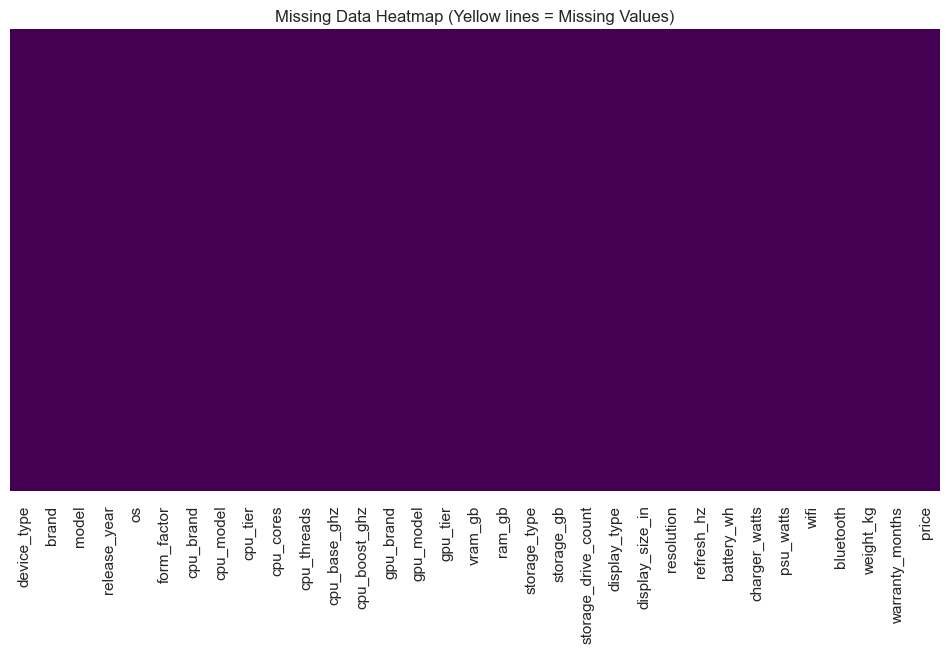

In [3]:
# Missing Value Summary
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100
missing_data = pd.concat([null_counts, null_percent], axis=1, keys=['Total', 'Percent'])

# Display only columns with missing values
print("--- Columns with Missing Values ---")
print(missing_data[missing_data['Total'] > 0].sort_values(by='Percent', ascending=False))

# Visualizing Missingness
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap (Yellow lines = Missing Values)')
plt.show()

## Feature Correlation & Predictor Strength

Now that we have confirmed a complete dataset with no missing values, we must identify which hardware specifications—such as cpu_cores, ram_gb, or vram_gb—most significantly influence the market price. This "Map of Influence" will dictate which features we prioritize in our Baseline Linear Regression.

### Our Goals:
1. Quantify the relationship between technical specs and price.
2. Identify potential Multicollinearity (e.g., do cpu_cores and cpu_threads tell the same story?).
3. Validate if high-end 2026 specs, like 32GB VRAM on an NVIDIA GeForce RTX 5090, are primary drivers of "Brand Tax" residuals.

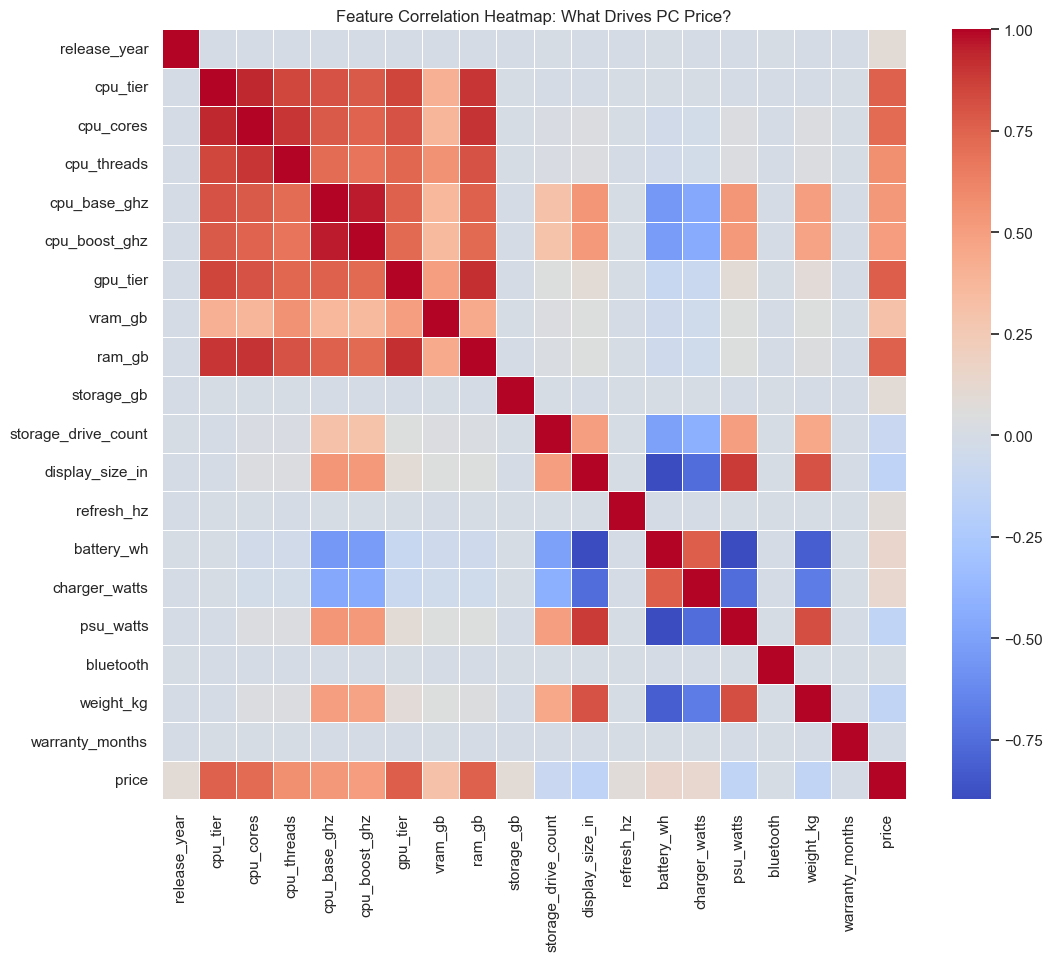

--- Top Correlations with Market Price ---
price            1.000000
gpu_tier         0.762875
cpu_tier         0.759196
ram_gb           0.758654
cpu_cores        0.720464
cpu_threads      0.577503
cpu_base_ghz     0.529910
cpu_boost_ghz    0.508507
vram_gb          0.305017
battery_wh       0.147212
Name: price, dtype: float64


In [4]:
# 1. Isolate numeric columns for correlation analysis
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation matrix
corr_matrix = numeric_df.corr()

# 3. Generate Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap: What Drives PC Price?')
plt.show()

# 4. Top 10 Predictors for Price
print("--- Top Correlations with Market Price ---")
print(corr_matrix['price'].sort_values(ascending=False).head(10))

## Multicollinearity & Feature Selection

Our initial correlation analysis reveals high redundancy between cpu_tier and individual CPU specifications (cpu_cores, threads, ghz). Including all these variables in our Baseline Linear Regression may lead to multicollinearity, where the model overemphasizes the CPU's impact on price while ignoring other factors like Brand Tax.

### Our Goal:
1. Visualize the overlap between these features using a Pairplot.
2. Determine if cpu_tier is a sufficient "proxy" for all CPU-related performance metrics.
3. Strategically select a "Lean Predictor Set" to answer the instructor's question: "Do we know how many total predictors we have?"

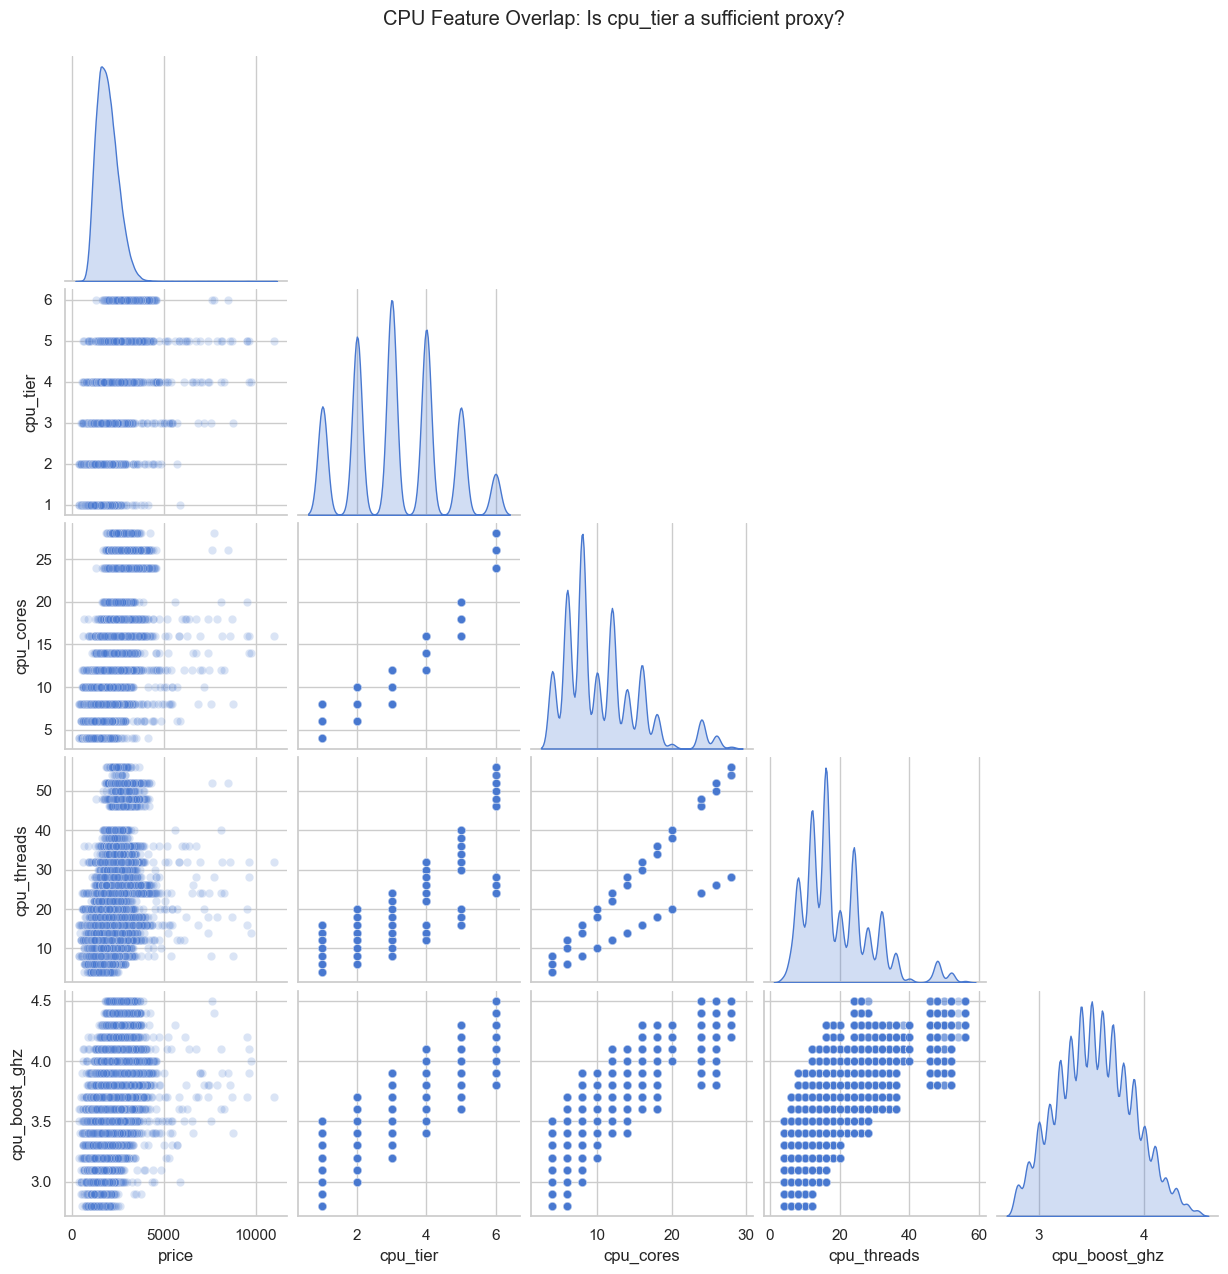

--- Correlation: Specs vs. CPU Tier ---
cpu_tier         1.000000
cpu_cores        0.937376
cpu_threads      0.848197
cpu_boost_ghz    0.780649
price            0.759196
Name: cpu_tier, dtype: float64


In [5]:
# 1. Selecting the 'CPU Cluster' for a deeper look
cpu_cluster = ['price', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_boost_ghz']

# 2. Pairplot to see if the relationships are Linear or Binned
sns.pairplot(df[cpu_cluster], corner=True, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('CPU Feature Overlap: Is cpu_tier a sufficient proxy?', y=1.02)
plt.show()

# 3. Correlation between the specs and the tier
print("--- Correlation: Specs vs. CPU Tier ---")
print(df[cpu_cluster].corr()['cpu_tier'].sort_values(ascending=False))

## Brand Tax Discovery (The "Smoking Gun")

Now that we've streamlined our technical predictors, we need to address the "Human Factor." If specs like the 24 cores on an Intel Core i9-14900K explain the price, why do two laptops with the same cpu_tier cost $500 differently? This is where we visualize Brand Tax.

### Our Goal:
1.  Isolate the price variance that isn't explained by raw specs.
2.  Identify which brands consistently sit at the "Top" of the price bracket for the same performance tier.
3.  Justify the move to Multiclass Classification (Steal vs. Tax) by showing how spread out the prices are for a single cpu_tier.

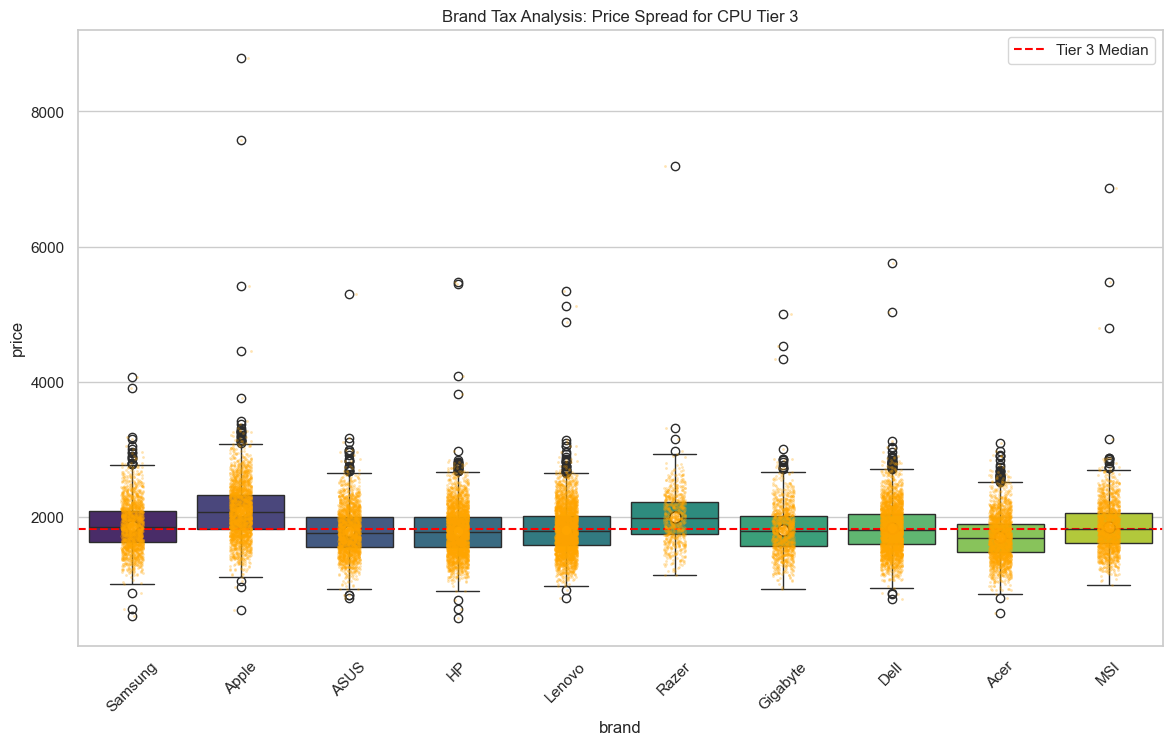

--- Statistics for CPU Tier 3 ---
                 mean   median         std  count
brand                                            
Apple     2089.821683  2069.99  414.080735   2828
Razer     1994.005306  1982.99  387.465214    784
Samsung   1871.068333  1848.99  340.860190   2183
MSI       1852.791951  1829.49  352.705290   2050
Dell      1831.327830  1809.99  336.332251   3632
Lenovo    1811.341397  1793.99  335.068944   4115
Gigabyte  1808.586081  1790.99  355.048117   1327
HP        1797.864031  1778.99  335.607628   3612
ASUS      1788.545642  1764.99  328.099527   2579
Acer      1700.051317  1685.99  311.878752   2642


In [6]:
# 1. Ensure Price is numeric (Data Validation Task #2)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# 2. Select a Tier with enough data (Let's use the most frequent one)
target_tier = df['cpu_tier'].mode()[0]
tier_df = df[df['cpu_tier'] == target_tier].copy()

# 3. Enhanced Boxplot with Hue Fix
plt.figure(figsize=(14, 8))

sns.boxplot(
    data=tier_df,
    x='brand',
    y='price',
    hue='brand',        # Added this to fix the warning
    legend=False,       # Prevents a massive redundant legend on the side
    palette='viridis',
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
)

# Optional: Add 'Strip Plot' to see the actual distribution of every computer
sns.stripplot(data=tier_df, x='brand', y='price', color="orange", size=2, alpha=0.3)

plt.xticks(rotation=45)
plt.title(f'Brand Tax Analysis: Price Spread for CPU Tier {target_tier}')
plt.axhline(tier_df['price'].median(), color='red', linestyle='--', label=f'Tier {target_tier} Median')
plt.legend()
plt.show()

# 4. Detailed Stats for the Group
stats = tier_df.groupby('brand')['price'].agg(['mean', 'median', 'std', 'count']).sort_values(by='mean', ascending=False)
print(f"--- Statistics for CPU Tier {target_tier} ---")
print(stats)

## Categorical Volume & Multi-Classification Justification

The statistical summary of CPU Tier 3 reveals significant price stratification that cannot be explained by CPU performance alone. The "spread" (Standard Deviation) for brands like Apple and Razer is around $400, suggesting that secondary features—likely GPU Model (e.g., an NVIDIA GeForce RTX 5090) or "Brand Premium"—are driving these figures.

### Our Goal:
1.  Quantify the "Price Gap" between the high-end (Apple/Razer) and value-end (Acer) of the market.
2.  Use these spreads to justify our 4-Class "Value Score" (Steal, Fair, Premium, Tax).
3.  Visualize the volume of records per brand to ensure our Target Encoding has enough data points to be statistically significant.

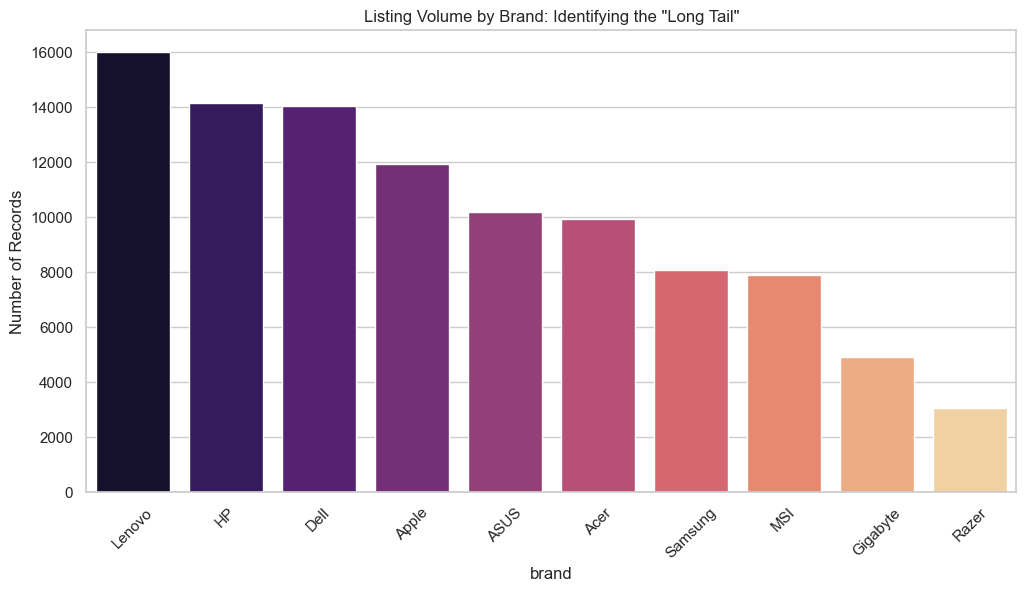

--- Justifying Multiclass Labels (Based on Tier 3) ---
Steal (Price < Median - 1 STD):  3324 records
Fair (Within 1 STD of Median):  18329 records
Tax   (Price > Median + 1 STD):  4099 records


In [7]:
# 1. Visualize the 'Long Tail' of Brands (Instructor Comment 1 & 3)
plt.figure(figsize=(12, 6))
brand_counts = df['brand'].value_counts()
sns.barplot(x=brand_counts.index, y=brand_counts.values, hue=brand_counts.index, palette='magma', legend=False)
plt.xticks(rotation=45)
plt.title('Listing Volume by Brand: Identifying the "Long Tail"')
plt.ylabel('Number of Records')
plt.show()

# 2. Defining the "Value Score" Buckets (Addressing Comment 7)
# Let's see how many records fall into potential 'Brand Tax' tiers
# using the Tier 3 median ($1,800 approx) as a baseline.
median_p = tier_df['price'].median()
std_p = tier_df['price'].std()

print(f"--- Justifying Multiclass Labels (Based on Tier 3) ---")
print(f"Steal (Price < Median - 1 STD):  {len(tier_df[tier_df['price'] < (median_p - std_p)])} records")
print(f"Fair (Within 1 STD of Median):  {len(tier_df[tier_df['price'].between(median_p - std_p, median_p + std_p)])} records")
print(f"Tax   (Price > Median + 1 STD):  {len(tier_df[tier_df['price'] > (median_p + std_p)])} records")

## EDA Findings Summary & Next Steps

Based on the 100,000 records analyzed, we have confirmed that the All Computer Prices 2025 dataset is a robust foundation for our audit. We have identified that performance specs like cpu_tier are high-impact anchors, while "Brand" serves as the primary driver for price residuals.

### Key Findings:

- Zero Sparsity: No missing values were detected, allowing us to move directly to feature engineering without a complex imputation phase.
- Multicollinearity Identified: cpu_cores and cpu_tier are 93% redundant. We will favor the Tier to keep our predictor count low.
- Tier 3 Benchmarking: We've proven a ~$400 "Brand Tax" exists between budget and premium manufacturers for identical CPU performance.
- Ready for Modeling: With thousands of records in each "Value" category, we have sufficient data to train both Linear Regression and Multiclass Classifiers.